In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
import sys
sys.path.append('/home/jovyan/work/base_demo')
import base_tool

In [65]:
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

数据介绍

bid_book_begin 集合竞价后的完整委托买入订单簿

ask_book_begin 集合竞价后的完整委托卖出订单簿

snap_list 连续竞价阶段的1s快照
    time_hms  时分秒字符串
    time_mark 毫秒级时间戳
    price_open 快照内首个成交价(无成交时为0.0)
    price_low  快照内最低成交价(无成交时为0.0)
    price_high 快照内最高成交价(无成交时为0.0)
    price_last 当日内最新成交价
     buy_trade 主动买入成交
    sell_trade 主动卖出成交
    bid_insert 委托买入挂单
    ask_insert 委托卖出挂单
    bid_cancel 委托买入撤单
    ask_cancel 委托卖出撤单

511520 511090 518880

In [66]:
import numpy as np
from typing import List, Dict, Any, Optional

class FeatureExtractor:
    def __init__(self, snap_slice: List[Dict[str, Any]]):
        if not snap_slice:
            raise ValueError("snap_slice cannot be empty")
        self.snap_slice = snap_slice
        self.last = snap_slice[-1]
        self.bid_book = self.last.get('bid_book', [])
        self.ask_book = self.last.get('ask_book', [])
        
    @staticmethod
    def _safe_get_level(book: List[tuple], idx: int = 0) -> tuple:
        if book and len(book) > idx:
            return book[idx]
        return (np.nan, 0)
    
    @property
    def price_last(self) -> float:
        return self.last.get('price_last', np.nan)
    
    @property
    def best_bid(self) -> float:
        return self._safe_get_level(self.bid_book)[0]
    
    @property
    def best_ask(self) -> float:
        return self._safe_get_level(self.ask_book)[0]
    
    @property
    def spread(self) -> float:
        bid, ask = self.best_bid, self.best_ask
        if np.isnan(bid) or np.isnan(ask):
            return np.nan
        return ask - bid
    
    @property
    def volatility(self) -> float:
        prices = [snap['price_last'] for snap in self.snap_slice 
                  if snap.get('price_last') is not None]
        if len(prices) < 2:
            return 0.0
        mean_price = np.mean(prices)
        if mean_price == 0:
            return 0.0
        return np.std(prices) / mean_price
    
    @property
    def obi(self) -> float:
        bid_vol = self._safe_get_level(self.bid_book)[1]
        ask_vol = self._safe_get_level(self.ask_book)[1]
        total = bid_vol + ask_vol
        return (bid_vol - ask_vol) / total if total != 0 else 0.0
    
    @property
    def deep_obi(self) -> float:
        bid_vol = sum(level[1] for level in self.bid_book[:5]) if self.bid_book else 0
        ask_vol = sum(level[1] for level in self.ask_book[:5]) if self.ask_book else 0
        total = bid_vol + ask_vol
        return (bid_vol - ask_vol) / total if total != 0 else 0.0
    
    @property
    def wamp(self) -> float:
        bid_price, bid_vol = self._safe_get_level(self.bid_book)
        ask_price, ask_vol = self._safe_get_level(self.ask_book)
        numerator = bid_price * bid_vol + ask_price * ask_vol
        denominator = bid_vol + ask_vol
        if denominator == 0 or np.isnan(numerator):
            return 0.0
        return numerator / denominator
        
    
    def extract_all(self) -> Dict[str, Any]:
        return {
            'price_last': self.price_last,
            'num_trades': self.last.get('num_trades', 0),
            'best_bid': self.best_bid,
            'best_ask': self.best_ask,
            'volatility': self.volatility,
            'spread': self.spread,
            'OBI': self.obi,
            'deep_OBI': self.deep_obi,
            'WAMP': self.wamp,
        }

def create_feature(snap_slice: List[Dict[str, Any]]) -> Dict[str, Any]:
    return FeatureExtractor(snap_slice).extract_all()

In [67]:
import numpy as np

class TrainValidTest():
    def __init__(self, snap_list, param_dict, feature_func, y_func):
        if param_dict is not None:
            self.__dict__.update(param_dict)
        
        # 确保必要属性存在
        if not hasattr(self, 'x_window'):
            self.x_window = 1
        if not hasattr(self, 'y_window'):
            self.y_window = 1
        if not hasattr(self, 'short_window'):
            self.short_window = 5
        if not hasattr(self, 'long_window'):
            self.long_window = 20

        self.snap_list = snap_list.copy()
        self.create_feature = feature_func
        self.create_y = y_func

        # 预计算滚动均线 → 改为 EMA
        prices = pd.Series([snap['price_last'] for snap in snap_list])
        self.short_ma = prices.ewm(span=self.short_window, adjust=False, min_periods=1).mean()
        self.long_ma = prices.ewm(span=self.long_window, adjust=False, min_periods=1).mean()

    def samples(self):
        feature_records = []   # 存放特征字典
        labels = []            # 存放标签（标量）
        n = len(self.snap_list)
        stride = getattr(self, 'stride', 1)

        for i in range(self.x_window, n - self.y_window, stride):
            flag, category = self.trigger(i)
            if not flag:
                continue
            # 提取特征（返回字典）
            x_dict = self.create_feature(self.snap_list[i - self.x_window:i])
            # 直接从字典获取 volatility，避免 .iloc
            volatility = x_dict.get('volatility', 0.0)
            y_val = self.create_y(
                self.snap_list[i:i + self.y_window],
                volatility, self.k_up, self.k_down, category
            )
            feature_records.append(x_dict)
            labels.append(y_val)

        if not feature_records:
            return pd.DataFrame(), pd.Series(dtype=float)

        X_all = pd.DataFrame(feature_records)
        y_all = pd.Series(labels)
        return X_all, y_all

    def trigger(self, time):
        short_curr = self.short_ma.iloc[time]
        long_curr = self.long_ma.iloc[time]
        short_prev = self.short_ma.iloc[time-1]
        long_prev = self.long_ma.iloc[time-1]

        if short_curr <= long_curr and short_prev > long_prev:
            return True, 1
        elif short_curr >= long_curr and short_prev < long_prev:
            return True, -1
        else:
            return False, 0

def samples_from_dates(dates, instrument_id, param_dict, create_feature, create_y):
    X_all_list = []
    y_all_list = []
    
    for date in dates:
        try:
            snap_list = base_tool.snap_list_load(instrument_id, date)
            if len(snap_list) < param_dict['x_window'] + param_dict['y_window']:
                print(f"{date}: 数据不足，跳过")
                continue
            tv = TrainValidTest(snap_list, param_dict, create_feature, create_y)
            X_day, y_day = tv.samples()
            X_all_list.append(X_day)
            y_all_list.append(y_day)
            print(f"{date}: 产生 {len(X_day)} 个样本")
        except Exception as e:
            print(f"{date}: 加载失败 - {e}")
    
    if X_all_list:
        X_total = pd.concat(X_all_list, axis=0, ignore_index=True)
        y_total = pd.concat(y_all_list, axis=0, ignore_index=True)
    else:
        X_total = pd.DataFrame()
        y_total = pd.Series()
    
    return X_total, y_total

def create_y(snap_slice, volatility, k_up, k_down,category):
    # 初始化突破时间索引为 None
    t_up = None
    t_down = None

    start = snap_slice[0]['price_last']
    if start is None or start == 0 or pd.isna(start):
        return pd.Series([0])

    up = start * (1 + volatility * k_up)
    down = start * (1 - volatility * k_down)

    for i in range(1, len(snap_slice)):
        price = snap_slice[i]['price_last']
        if price is None or pd.isna(price):
            continue

        if t_up is None and price >= up:
            t_up = i
        if t_down is None and price <= down:
            t_down = i

        if t_up is not None and t_down is not None:
            break

    # 根据触发情况决定标签
    if t_up is not None and t_down is not None:
        label = 1 if t_up < t_down else -1
    elif t_up is not None:
        label = 1
    elif t_down is not None:
        label = -1
    else:
        label = 0

    if category == label:
        label = 1
    else:
        label = 0

    return label





In [68]:
from collections import deque
import os
import pandas as pd
from typing import Dict, Any

class StrategyDemo():
    def __init__(self, model, param_dict={}) -> None:
        self.__dict__.update(param_dict)
        
        data_file = f'/home/jovyan/work/backtest_result/{self.instrument_id}_{self.trade_ymd}_{self.name}.pkl'
        try:
            if os.path.exists(data_file):
                os.remove(data_file)
        except OSError as e:
            print(f"Warning: Could not delete file {data_file}: {e}")

        self.position_last = 0
        self.model = model
        
        # 特征缓冲区（保持原样，用于 create_feature）
        self.feature_buffer = deque(maxlen=self.x_window)
        
        # ----- EMA 状态变量（替代 price_list 和 price_sum）-----
        self.short_ema = None      # 当前短期 EMA 值
        self.long_ema = None       # 当前长期 EMA 值
        # 平滑系数，预先算好
        self.alpha_short = 2.0 / (self.short_window + 1)
        self.alpha_long  = 2.0 / (self.long_window + 1)
        
        self.prev_signal = 0

    def on_snap(self, snap: Dict[str, Any]) -> None:
        price = snap.get('price_last')
        if not price:
            return

        # ---------- EMA 增量更新（O(1)）----------
        if self.short_ema is None:          # 第一个价格，初始化
            self.short_ema = price
            self.long_ema = price
            self.feature_buffer.append(snap)   # 仍需积累特征
            self.position_last = 0
            self.prev_signal = 0
            return

        # 递归更新
        self.short_ema = self.alpha_short * price + (1 - self.alpha_short) * self.short_ema
        self.long_ema  = self.alpha_long  * price + (1 - self.alpha_long)  * self.long_ema
        diff = self.short_ema - self.long_ema

        # ---------- 特征工程（保持原逻辑）----------
        self.feature_buffer.append(snap)
        if len(self.feature_buffer) == self.x_window:
            feat_dict = create_feature(self.feature_buffer)   # 需要事先定义
            features_df = pd.DataFrame([feat_dict])
            prob = self.model.predict_proba(features_df)[:, 1][0]
        else:
            return   # 特征不足，不产生信号

        # ---------- 信号生成 ----------
        if diff > 0:
            current_signal = 1
        elif diff < 0:
            current_signal = -1
        else:
            current_signal = 0

        if current_signal != self.prev_signal and prob > self.threshold:
            self.position_last = current_signal
            self.prev_signal = current_signal

In [69]:
instrument_id = '518880'
trade_ymd = '20260319'

In [70]:
param_dict = {

    'instrument_id' : instrument_id,
    'trade_ymd' : trade_ymd,
    
    'short_window' : 60 ,
    'long_window' : 300 , 
    'threshold' : 0.5 ,
    'name' : 'EMA_v1',

    'y_window' : 300 ,
    'stride': 1,

    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'],param_dict['long_window'])


In [71]:
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, classification_report

train_days = 35
valid_days = 9
test_days = 10

trade_dates = ["20260105"
,"20260106"
,"20260107"
,"20260108"
,"20260109"
,"20260112"
,"20260113"
,"20260114"
,"20260115"
,"20260116"
,"20260119"
,"20260120"
,"20260121"
,"20260122"
,"20260123"
,"20260126"
,"20260127"
,"20260128"
,"20260129"
,"20260130"
,"20260202"
,"20260203"
,"20260204"
,"20260205"
,"20260206"
,"20260209"
,"20260210"
,"20260211"
,"20260212"
,"20260213"
,"20260224"
,"20260225"
,"20260226"
,"20260227"
,"20260302"
,"20260303"
,"20260304"
,"20260305"
,"20260306"
,"20260309"
,"20260310"
,"20260311"
,"20260312"
,"20260313"
,"20260316"
,"20260317"
,"20260318"
,"20260319"
,"20260320"
,"20260323"
,"20260324"
,"20260325"
,"20260326"
,"20260327"]
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

总交易日数量: 54
交易日范围: 20260105 ~ 20260327


In [72]:
train_dates = trade_dates[:train_days]
valid_dates = trade_dates[train_days:train_days + valid_days]
test_dates = trade_dates[train_days + valid_days:train_days + valid_days + test_days]

print(f"训练集: {train_dates[0]} ~ {train_dates[-1]} ({len(train_dates)}天)")
print(f"验证集: {valid_dates[0]} ~ {valid_dates[-1]} ({len(valid_dates)}天)")
print(f"测试集: {test_dates[0]} ~ {test_dates[-1]} ({len(test_dates)}天)")

训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


In [73]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...


20260105: 产生 90 个样本
20260106: 产生 79 个样本
20260107: 产生 78 个样本
20260108: 产生 59 个样本
20260109: 产生 65 个样本
20260112: 产生 95 个样本
20260113: 产生 73 个样本
20260114: 产生 77 个样本
20260115: 产生 47 个样本
20260116: 产生 61 个样本
20260119: 产生 96 个样本
20260120: 产生 63 个样本
20260121: 产生 42 个样本
20260122: 产生 52 个样本
20260123: 产生 70 个样本
20260126: 产生 55 个样本
20260127: 产生 64 个样本
20260128: 产生 60 个样本
20260129: 产生 67 个样本
20260130: 产生 53 个样本
20260202: 产生 28 个样本
20260203: 产生 48 个样本
20260204: 产生 51 个样本
20260205: 产生 51 个样本
20260206: 产生 39 个样本
20260209: 产生 65 个样本
20260210: 产生 81 个样本
20260211: 产生 61 个样本
20260212: 产生 76 个样本
20260213: 产生 66 个样本
20260224: 产生 77 个样本
20260225: 产生 89 个样本
20260226: 产生 97 个样本
20260227: 产生 105 个样本
20260302: 产生 53 个样本
训练集样本: X=(2333, 9), y=(2333,)
标签分布:
0    1575
1     758
Name: count, dtype: int64


In [74]:
%%time
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 52 个样本
20260304: 产生 63 个样本
20260305: 产生 58 个样本
20260306: 产生 67 个样本
20260309: 产生 62 个样本
20260310: 产生 76 个样本
20260311: 产生 68 个样本
20260312: 产生 50 个样本
20260313: 产生 75 个样本
验证集样本: X=(571, 9), y=(571,)
标签分布:
0    386
1    185
Name: count, dtype: int64
CPU times: user 3.64 s, sys: 27 ms, total: 3.67 s
Wall time: 3.66 s


In [75]:
%%time
scale_pos_weight_value = (y_train == 0).sum() / (y_train != 0).sum() if (y_train != 0).sum() > 0 else 1.0
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=10
)

[0]	validation_0-logloss:0.69243
[10]	validation_0-logloss:0.68853
[20]	validation_0-logloss:0.68546
[30]	validation_0-logloss:0.68237
[40]	validation_0-logloss:0.67885
[50]	validation_0-logloss:0.67563
[60]	validation_0-logloss:0.67339
[70]	validation_0-logloss:0.67065
[80]	validation_0-logloss:0.66876
[90]	validation_0-logloss:0.66732
[100]	validation_0-logloss:0.66662
[110]	validation_0-logloss:0.66540
[120]	validation_0-logloss:0.66314
[130]	validation_0-logloss:0.66188
[140]	validation_0-logloss:0.66084
[150]	validation_0-logloss:0.65967
[160]	validation_0-logloss:0.65857
[170]	validation_0-logloss:0.65740
[180]	validation_0-logloss:0.65689
[190]	validation_0-logloss:0.65631
[200]	validation_0-logloss:0.65587
[210]	validation_0-logloss:0.65523
[220]	validation_0-logloss:0.65482
[230]	validation_0-logloss:0.65459
[240]	validation_0-logloss:0.65425
[250]	validation_0-logloss:0.65405
[260]	validation_0-logloss:0.65410
[270]	validation_0-logloss:0.65390
[280]	validation_0-logloss:0.65

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

验证集准确率: 0.6199649737302977
分类报告:
              precision    recall  f1-score   support

      不可信(0)       0.72      0.73      0.72       386
       可信(1)       0.41      0.40      0.41       185

    accuracy                           0.62       571
   macro avg       0.56      0.56      0.56       571
weighted avg       0.62      0.62      0.62       571

In [76]:
y_pred = model.predict(X_valid)
print("验证集准确率:", accuracy_score(y_valid, y_pred))

unique_labels = sorted(set(y_valid.unique()) | set(np.unique(y_pred)))
label_names = { 0: '不可信(0)', 1: '可信(1)' }
target_names = [label_names.get(l, str(l)) for l in unique_labels]
print("分类报告:")
print(classification_report(y_valid, y_pred, labels=unique_labels, target_names=target_names))

验证集准确率: 0.6199649737302977
分类报告:
              precision    recall  f1-score   support

      不可信(0)       0.72      0.73      0.72       386
       可信(1)       0.41      0.40      0.41       185

    accuracy                           0.62       571
   macro avg       0.56      0.56      0.56       571
weighted avg       0.62      0.62      0.62       571



In [77]:
model_path = f'/home/jovyan/work/backtest_result/{instrument_id}_xgb_model.pkl'
joblib.dump(model, model_path)
print(f"模型已保存至: {model_path}")


模型已保存至: /home/jovyan/work/backtest_result/518880_xgb_model.pkl


# 测试集表现

In [78]:
%%time
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...


20260316: 产生 66 个样本
20260317: 产生 56 个样本
20260318: 产生 82 个样本
20260319: 产生 47 个样本
20260320: 产生 61 个样本
20260323: 产生 53 个样本
20260324: 产生 68 个样本
20260325: 产生 43 个样本
20260326: 产生 49 个样本
20260327: 产生 58 个样本
测试集样本: X=(583, 9), y=(583,)
CPU times: user 3.99 s, sys: 54 ms, total: 4.05 s
Wall time: 4.04 s


In [79]:
import os
import sys
current_notebook_path = os.path.abspath('%pwd') 
current_dir = os.path.dirname(current_notebook_path)
parent_dir = os.path.dirname(current_dir)
utils_path = os.path.join(parent_dir, 'tools')
sys.path.append(utils_path)

In [ ]:
from backtesting import backtest_multi_days
param_dict['trade_ymd'] = ''
strategy = StrategyDemo(model,param_dict)
backtest_df = backtest_multi_days(instrument_id,'20260303','20260327',strategy,param_dict)

/home/jovyan/work/backtest_result/518880_20260303_EMA_v1.pkl 生成中
日期 20260303 回测完成，当日盈亏: 10.90
/home/jovyan/work/backtest_result/518880_20260304_EMA_v1.pkl 生成中
日期 20260304 回测完成，当日盈亏: -0.60
/home/jovyan/work/backtest_result/518880_20260305_EMA_v1.pkl 生成中
日期 20260305 回测完成，当日盈亏: -5.40
/home/jovyan/work/backtest_result/518880_20260306_EMA_v1.pkl 生成中
日期 20260306 回测完成，当日盈亏: -8.70

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
2026

In [ ]:
backtest_df

,trade_ymd,order_time,order_price,total,trade,cancel,hold,profit_last,profits,maxdd,MAR,pper,trade_date
0,20260304,2026-03-04 14:55:00,10.972,2,2,0,0,-0.9,-0.9,1.0,-0.90,-0.45,2026-03-04
1,20260305,2026-03-05 14:55:00,10.949,6,6,0,0,-4.1,-2.1,4.1,-0.51,-0.35,2026-03-05
2,20260309,2026-03-09 14:55:00,10.863,3,3,0,0,-0.3,-2.9,2.9,-1.00,-0.97,2026-03-09
3,20260310,2026-03-10 14:55:00,10.959,14,14,0,0,-0.1,1.8,1.4,1.29,0.13,2026-03-10
4,20260311,2026-03-11 14:55:00,10.972,33,32,1,0,0.7,1.4,1.6,0.87,0.04,2026-03-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,20260323,2026-03-23 14:55:00,8.933,2,2,0,0,53.6,53.6,1.0,53.60,26.80,2026-03-23
12,20260324,2026-03-24 14:55:00,9.271,2,2,0,0,-5.4,-5.4,5.4,-1.00,-2.70,2026-03-24
13,20260325,2026-03-25 14:55:00,9.642,2,2,0,0,8.4,8.4,1.0,8.40,4.20,2026-03-25
14,20260326,2026-03-26 14:55:00,9.447,4,4,0,0,17.1,16.6,1.0,16.60,4.15,2026-03-26


In [ ]:
from backtesting import backtest_summary
summary = backtest_summary(backtest_df)
print(summary)

{'交易天数': 16, '累计盈亏': np.float64(72.5), '最大单日盈利': 53.6, '最大单日亏损': -12.0, '盈利天数': 8, '亏损天数': 8, '平盘天数': 0, '胜率(%)': np.float64(50.0), '日均盈亏': np.float64(4.53), '盈亏比': np.float64(3.13)}


In [ ]:
summary

{'交易天数': 16,
 '累计盈亏': np.float64(72.5),
 '最大单日盈利': 53.6,
 '最大单日亏损': -12.0,
 '盈利天数': 8,
 '亏损天数': 8,
 '平盘天数': 0,
 '胜率(%)': np.float64(50.0),
 '日均盈亏': np.float64(4.53),
 '盈亏比': np.float64(3.13)}

In [ ]:
param_dict

{'instrument_id': '518880',
 'trade_ymd': '',
 'short_window': 60,
 'long_window': 300,
 'threshold': 0.7,
 'name': 'EMA_v1',
 'y_window': 300,
 'stride': 1,
 'k_up': 3,
 'k_down': 3,
 'x_window': 300}

In [ ]:

summary['short_window'] = param_dict['short_window']
summary['long_window'] = param_dict['long_window']
summary['threshold'] = param_dict['threshold']
summary

{'交易天数': 16,
 '累计盈亏': np.float64(72.5),
 '最大单日盈利': 53.6,
 '最大单日亏损': -12.0,
 '盈利天数': 8,
 '亏损天数': 8,
 '平盘天数': 0,
 '胜率(%)': np.float64(50.0),
 '日均盈亏': np.float64(4.53),
 '盈亏比': np.float64(3.13),
 'short_window': 60,
 'long_window': 300,
 'threshold': 0.7}

In [ ]:
type(summary)

dict

In [ ]:
# add dict summary to outcome dataframe
df = pd.DataFrame()  
new_df = pd.DataFrame([summary])
df = pd.concat([df, new_df], ignore_index=True)

In [ ]:
print(df)

   交易天数  累计盈亏  最大单日盈利  最大单日亏损  盈利天数  亏损天数  平盘天数  胜率(%)  日均盈亏   盈亏比  \
0    16  72.5    53.6   -12.0     8     8     0   50.0  4.53  3.13   

   short_window  long_window  threshold  
0            60          300        0.7  


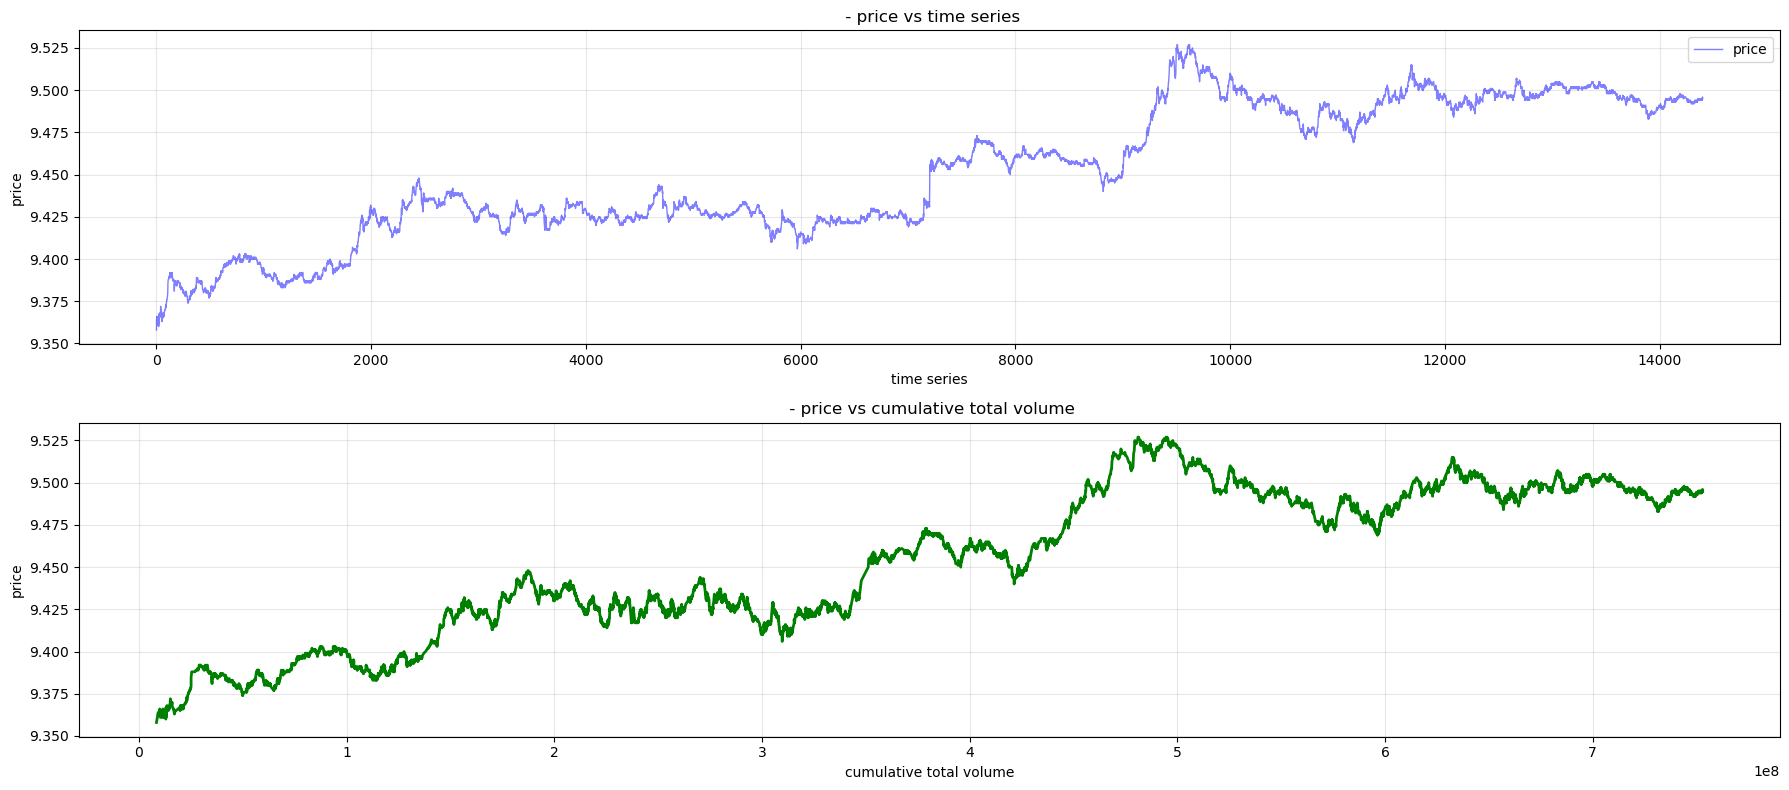

In [ ]:
from plot_price import plot_price_analysis
import matplotlib.pyplot as plt
  

snap_list = base_tool.snap_list_load(instrument_id, "20260327")
plot_price_analysis(snap_list)